In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import ParameterSequenceGenerator
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time
import imageio

In [3]:
# Select Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# Hyperparameters
N_grid = 100                            # Number of grid points for the parameter range
N_samples = 1000                        # Number of samples to generate for Monte Carlo estimations
entropy_weight = 10                     # Initial Entropy weight for the loss function
entropy_update_coefficient = 0.5        # Coefficient for updating the entropy weight
entropy_schedule = 1000                 # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.01           # Minimum entropy weight
num_epochs = 10000                      # Number of epochs to train the model

In [5]:
# Construct an IOCRN modeling a Gene Expression process
stoichiometry_reactants = np.array([[1, 0, 1, 0], [0, 1, 0, 0]], dtype=np.int8)
stoichiometry_products = np.array([[0, 0, 1, 1], [0, 0, 1, 0]], dtype=np.int8)
gamma_1 = 2; gamma_2 = 2; k = 4
true_parameters = np.array([gamma_1, gamma_2, k, 1], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 1]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_true = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, true_parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2']
inputs = ['u']
IOCRN_true.print_reactions(species, inputs)

Inputs: ['u']
Species: ['X_1', 'X_2']
Output Species: ['X_2']
Reaction 1: X_1 -> 0 ; Rate Constant: 2.0
Reaction 2: X_2 -> 0 ; Rate Constant: 2.0
Reaction 3: X_1 -> X_1 + X_2 ; Rate Constant: 4.0
Reaction 4: 0 -> X_1 ; Rate Constant: 1.0u


In [6]:
# Replace Dose response function with closed form solution
def dose_response(self, u_vec, param_vec):    
        if len(param_vec.shape) > 1:
            u_vec = np.tile(u_vec, (param_vec.shape[1], 1)).T 
        gamma_1 = param_vec[0]
        gamma_2 = param_vec[1]
        k = param_vec[2]
        c = param_vec[3]
        y_vec = k * c * u_vec / (gamma_1 * gamma_2)
        return y_vec
IOCRN_true.dose_response = types.MethodType(dose_response, IOCRN_true)

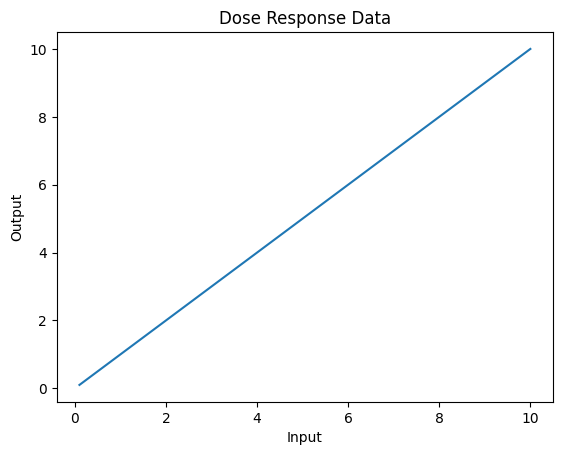

In [7]:
# Generate the dose response data
N_u = 100
u_Data = np.linspace(0.1, 10, N_u, dtype=np.float32)
# initial_guess = torch.tensor([0.1, 0.1]).float()
# y_Data = IOCRN_true.dose_response(u_Data, initial_guess, plot_flag=True)
y_Data = IOCRN_true.dose_response(u_Data, true_parameters)
y_Data = y_Data

# Plot the dose response data
plt.plot(u_Data, y_Data)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Dose Response Data')
plt.show()

In [8]:
# Construct the IOCRN with unknown parameters and the parameter grid
MyIOCRN = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, [], input_influence_matrix, outputs)
MyIOCRN.dose_response = types.MethodType(dose_response, MyIOCRN)
N_parameters = 3
theta_1 = np.linspace(1, 5, N_grid, dtype=np.float32)
theta_2 = np.linspace(1, 5, N_grid, dtype=np.float32)
theta_3 = np.linspace(1, 25, N_grid, dtype=np.float32)
theta_4 = np.linspace(1, 1, N_grid,  dtype=np.float32)
parameter_grid = np.stack([theta_1, theta_2, theta_3, theta_4], axis=0)

In [9]:
# Construct the Parameter Sequence Generator
MyPSG = ParameterSequenceGenerator(MyIOCRN, parameter_grid, LSTM_hidden_size=128, FFNN_hidden_size=128, FFNN_num_layers=5, num_samples=N_samples).to(device)

In [ ]:
# Create the initialize plot function
def initialize_plot(width, height, dpi):
    # Add subplots
    fig = plt.figure(figsize=(width, height))
    fig.set_dpi(dpi)
    gs = gridspec.GridSpec(2, 3)
    ax1 = fig.add_subplot(gs[:, 0], projection='3d')
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[1, 2])
    return fig, ax1, ax2, ax3, ax4, ax5

# Create the update plot function
def update_plot(fig, ax1, ax2, ax3, ax4, ax5, parameter_grid, true_parameters, parameters, u_Data, y_Data, CRN_outputs, entropy_weight_history, loss_history, entropy_history):
    gamma_1 = true_parameters[0]
    gamma_2 = true_parameters[1]
    k = true_parameters[2]
    theta_1 = parameter_grid[0,:]
    theta_2 = parameter_grid[1,:]
    theta_1_mesh, theta_2_mesh = np.meshgrid(theta_1, theta_2)
    rho = k / gamma_1 / gamma_2
    theta_3_mesh = (theta_1_mesh * theta_2_mesh) * rho
    # Plot the results
    ax1.clear()
    ax1.plot_surface(theta_1_mesh, theta_2_mesh, theta_3_mesh, cmap='hsv', alpha=0.5)
    ax1.scatter(parameters[0], parameters[1], parameters[2], c='b', marker='o', alpha=0.05)
    ax1.set_xlim(parameter_grid[0,0], parameter_grid[0,-1])
    ax1.set_ylim(parameter_grid[1,0], parameter_grid[1,-1])
    ax1.set_zlim(parameter_grid[2,0], parameter_grid[2,-1])
    ax2.clear()
    ax2.plot(u_Data, y_Data, 'r', alpha = 0.5)
    ax2.plot(u_Data, CRN_outputs, 'b', alpha=0.01)
    ax3.clear()
    ax3.plot(entropy_weight_history)
    ax4.clear()
    ax4.plot(loss_history)
    ax5.clear()
    ax5.plot(entropy_history)
    # Set the labels and titles
    ax1.set_xlabel('gamma_1')
    ax1.set_ylabel('gamma_2')
    ax1.set_zlabel('k')
    ax1.set_title('Parameter Space')
    ax2.set_xlabel('Input')
    ax2.set_ylabel('Output')
    ax2.set_title('Dose Response')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Entropy Weight')
    ax3.set_title('Entropy Weight History')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.set_title('Loss History')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Entropy')
    ax5.set_title('Entropy History')
    # Adjust the layout
    plt.tight_layout()
    return fig

# Create the image writer
def update_frame(fig, frames):
    fig.canvas.draw()
    buffer, (width, height) = fig.canvas.print_to_buffer() 
    image = np.frombuffer(buffer, dtype='uint8').reshape((height, width, 4))  
    image = image[:, :, :3]  
    frames.append(image)
    return frames

In [11]:
# Train the parameter generator
Animation_Flag = True
manifold_dim = 0
h0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float().to(device)
c0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float().to(device)
optimizer = torch.optim.Adam(MyPSG.parameters(), lr=0.001)
loss_history = []
entropy_history = []
entropy_weight_history = []
frames = []
fig, ax1, ax2, ax3, ax4, ax5 = initialize_plot(width=14, height=7, dpi=100)
tic = time.time()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss_for_each_sample, loss_mean, total_logPs, total_entropy, parameters, CRN_outputs = MyPSG.compute_loss(u_Data, y_Data, h0, c0, manifold_dim)
    entropy_mean = torch.mean(total_entropy)
    loss_for_gradient = torch.mean(loss_for_each_sample * total_logPs) - entropy_weight * entropy_mean - torch.mean(entropy_weight * total_entropy.detach() * total_logPs)
    loss_for_gradient.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print('Epoch: %d, Mean Loss: %.4f, Entropy: %.4f, Entropy Weight: %.4f' % (epoch, loss_mean.item(), entropy_mean.item(), entropy_weight))
        if Animation_Flag:
            loss_history.append(loss_mean.item())
            entropy_history.append(entropy_mean.item())
            entropy_weight_history.append(entropy_weight)
            fig = update_plot(fig, ax1, ax2, ax3, ax4, ax5, parameter_grid, true_parameters, parameters, u_Data, y_Data, CRN_outputs, entropy_weight_history, loss_history, entropy_history)
            frames = update_frame(fig, frames)
    if epoch % entropy_schedule == 0 and epoch != 0:
        entropy_weight = max(entropy_weight * entropy_update_coefficient, minimum_entropy_weight)
toc = time.time()
print('Training Time: %.2f' % (toc - tic))

if Animation_Flag:
    imageio.mimsave('Animation_Param3_dim2_GeneExp_Seed.gif', frames, fps=10, loop=0)
    plt.close(fig)

Epoch: 0, Mean Loss: 7.4821, Entropy: 23.0163, Entropy Weight: 10.0000
Epoch: 100, Mean Loss: 7.0095, Entropy: 23.0003, Entropy Weight: 10.0000
Epoch: 200, Mean Loss: 6.6480, Entropy: 23.0025, Entropy Weight: 10.0000
Epoch: 300, Mean Loss: 6.4058, Entropy: 22.9500, Entropy Weight: 10.0000
Epoch: 400, Mean Loss: 5.8043, Entropy: 22.9633, Entropy Weight: 10.0000
Epoch: 500, Mean Loss: 5.9686, Entropy: 22.9852, Entropy Weight: 10.0000
Epoch: 600, Mean Loss: 5.5630, Entropy: 22.9328, Entropy Weight: 10.0000
Epoch: 700, Mean Loss: 5.5952, Entropy: 22.9332, Entropy Weight: 10.0000
Epoch: 800, Mean Loss: 5.2237, Entropy: 22.8555, Entropy Weight: 10.0000
Epoch: 900, Mean Loss: 3.9432, Entropy: 22.5759, Entropy Weight: 10.0000
Epoch: 1000, Mean Loss: 5.2659, Entropy: 22.9598, Entropy Weight: 10.0000
Epoch: 1100, Mean Loss: 3.8655, Entropy: 22.8474, Entropy Weight: 5.0000
Epoch: 1200, Mean Loss: 3.4147, Entropy: 22.8286, Entropy Weight: 5.0000
Epoch: 1300, Mean Loss: 3.7940, Entropy: 22.8258, En

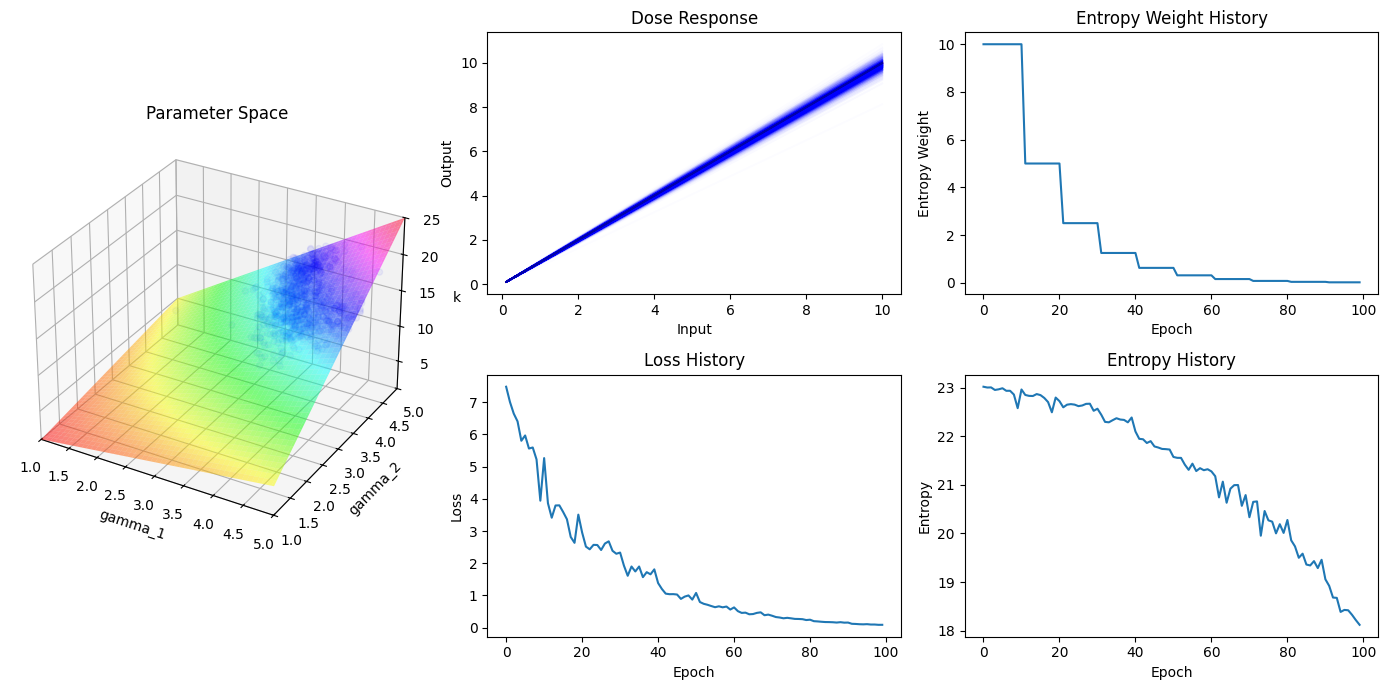

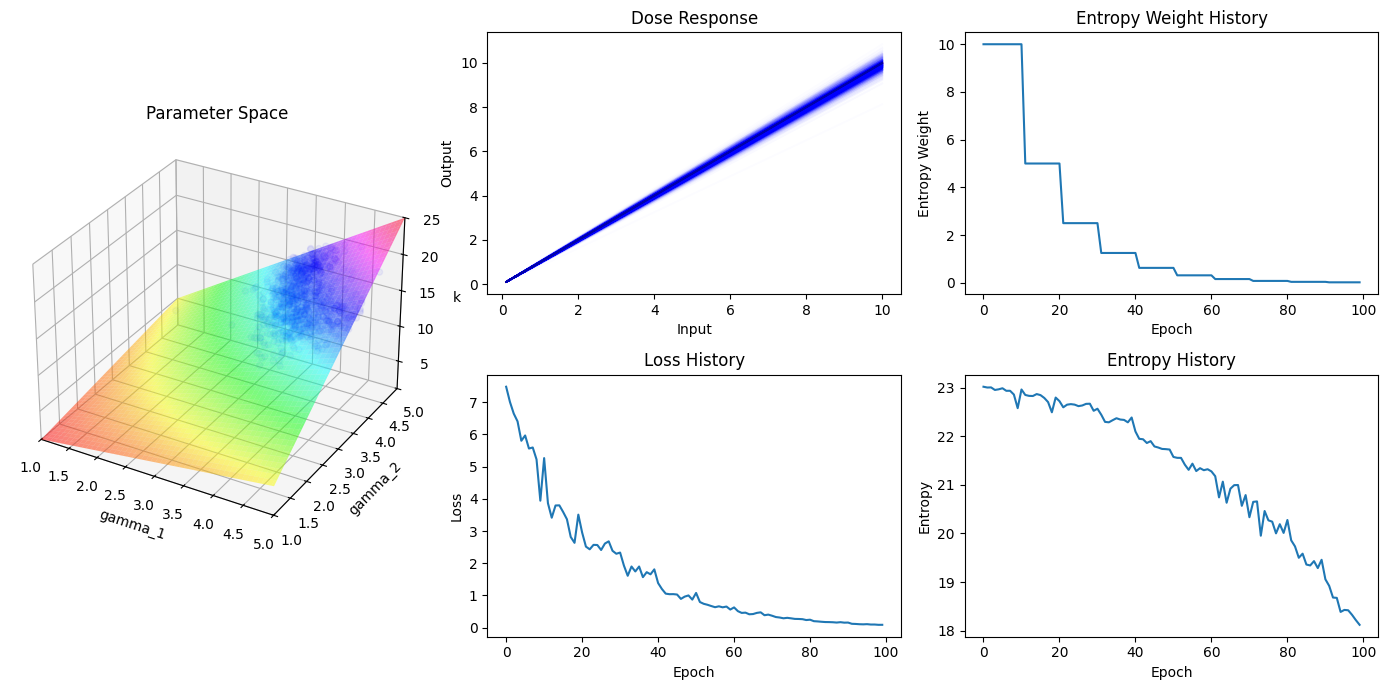

In [12]:
# Test the trained model
MyPSG.num_samples = 1000
h0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float()
c0 = torch.ones(MyPSG.num_samples, MyPSG.LSTM_hidden_size).float()
indices, _, _ = MyPSG(h0, c0, manifold_dim)
parameters = MyPSG.map_index_to_parameter(indices, parameter_grid)
CRN_outputs = MyIOCRN.dose_response(u_Data, parameters)

# Plot the results
fig, ax1, ax2, ax3, ax4, ax5 = initialize_plot(width=14, height=7, dpi=100)
update_plot(fig, ax1, ax2, ax3, ax4, ax5, parameter_grid, true_parameters, parameters, u_Data, y_Data, CRN_outputs, entropy_weight_history, loss_history, entropy_history)